# Exoplanetas: lo que sabemos está moldeado por cómo buscamos

Análisis exploratorio (EDA) de la población de exoplanetas confirmados del
[NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/).

**Tesis central:** el método usado para descubrir un exoplaneta (tránsito,
velocidad radial, microlente, imagen directa) condiciona *qué* planetas
encontramos — y por lo tanto distorsiona lo que creemos saber sobre la
población real de exoplanetas.

**Fuente de datos:** tabla `PSCompPars` (Planetary Systems Composite
Parameters), que consolida una fila por planeta confirmado. Se descarga de
forma reproducible con `src/download_data.py` vía el servicio TAP del archivo.

## 📖 Glosario rápido

Este análisis se puede leer sin saber astronomía. Acá están los términos que
van a aparecer, para consultar cuando haga falta.

**Los cuatro métodos de detección**

| Término | Qué significa |
|---|---|
| **Tránsito** | Detecta la mini-baja de brillo cuando un planeta pasa por delante de su estrella (una micro-eclipse). Favorece planetas grandes y pegados a su estrella, que transitan seguido. |
| **Velocidad radial** | Detecta el "bamboleo" de la estrella causado por el tirón gravitacional del planeta, midiendo el corrimiento Doppler de su luz. Favorece planetas masivos y cercanos. |
| **Microlente (gravitacional)** | La gravedad de una estrella (y sus planetas) amplifica la luz de otra estrella más lejana al pasar por delante. Es un evento único e irrepetible — por eso deja tantos datos sin medir. |
| **Imagen directa** | Fotografiar el planeta como un punto de luz separado de su estrella. Solo funciona con planetas gigantes, jóvenes (aún calientes) y muy alejados de su estrella. |

**Unidades y variables físicas**

| Término | Qué significa |
|---|---|
| **UA** (Unidad Astronómica) | La distancia Tierra–Sol: ~150 millones de km. Júpiter está a 5,2 UA; Neptuno a 30. |
| **M⊕ / R⊕** | Masa y radio en unidades terrestres (la Tierra = 1). Júpiter tiene ~318 M⊕ y ~11 R⊕. |
| **Semi-eje mayor** (`pl_orbsmax`) | El "radio" de la órbita: qué tan lejos está el planeta de su estrella, en UA. |
| **Período orbital** (`pl_orbper`) | Cuánto dura el "año" del planeta, en días. Está ligado al semi-eje por la 3ª ley de Kepler ($P^2 \propto a^3$): más lejos = año más largo. |
| **Temperatura de equilibrio** (`pl_eqt`, T$_{eq}$) | Temperatura teórica del planeta según la energía que recibe de su estrella, **sin considerar atmósfera**. La de la Tierra es 255 K (−18 °C); la superficie real promedia 288 K (15 °C) gracias al efecto invernadero. |
| **Parsec** (`sy_dist`) | Unidad de distancia entre estrellas: ~3,26 años luz. |

**Objetos y conceptos astronómicos**

| Término | Qué significa |
|---|---|
| **Enana roja** (tipo M) | Estrella pequeña y fría (~2.500–4.000 K vs. los 5.772 K del Sol). Son las estrellas más comunes de la galaxia. |
| **Enana café** | Objeto a medio camino entre planeta gigante y estrella (sobre ~13 masas de Júpiter): no logra sostener fusión nuclear. |
| **Super-Tierra / sub-Neptuno** | Familias de planetas entre la Tierra y Neptuno en tamaño. Son lo más común del catálogo — y no existen en el Sistema Solar. |
| **Júpiter caliente** | Gigante gaseoso orbitando a días de su estrella, a más de 1.000 K. Fue la primera gran sorpresa de la exoplanetología (51 Pegasi b, 1995). |
| **Zona habitable / templada** | Franja de distancias a una estrella donde un planeta podría tener agua líquida en superficie. |
| **Línea de hielo** | Distancia en el disco de formación más allá de la cual el agua se congela; se cree que ahí nacen los planetas gigantes (~2,7 UA en el Sistema Solar). |
| **Radius valley** | Escasez observada de planetas de ~1,8 R⊕: los mundos parecen ser rocosos (más chicos) o tener envoltura de gas (más grandes), con un "valle" entre medio. |
| **Kepler / TESS** | Telescopios espaciales de la NASA cazadores de tránsitos. Kepler (2009–2018) descubrió la mayoría del catálogo; TESS lo continúa desde 2018. |

**Términos de datos y estadística**

| Término | Qué significa |
|---|---|
| **TAP / ADQL** | El protocolo de consulta del NASA Exoplanet Archive y su dialecto de SQL para astronomía. Permiten descargar los datos por URL de forma reproducible. |
| **`Msini`** | Cota inferior de la masa: velocidad radial mide $M \cdot \sin(i)$ y la inclinación $i$ de la órbita suele ser desconocida, así que la masa real puede ser mayor. |
| **Relación masa-radio (M-R)** | Fórmula empírica que estima la masa de un planeta a partir de su radio. Útil, pero es una estimación estadística — no una medición. |
| **MNAR** (*missing not at random*) | Datos faltantes cuya ausencia tiene causa sistemática (aquí: el método de detección). Es el caso más peligroso de datos faltantes: imputarlos o botarlos distorsiona el análisis. |
| **ESI** (*Earth Similarity Index*) | Score de 0 a 1 que mide el parecido de un planeta con la Tierra combinando variables físicas (1 = idéntico). |
| **k-means / inercia / silueta** | Algoritmo de clustering que agrupa puntos por cercanía, y las dos métricas para elegir cuántos grupos usar (se explican en detalle en la sección 6). |

## 1. Carga de datos

El CSV crudo vive en `data/raw/` y nunca se edita a mano. Si el archivo no
existe, hay que generarlo primero corriendo (desde la raíz del repo):

```
python src/download_data.py
```

In [1]:
from pathlib import Path

import pandas as pd

# Ruta relativa al notebook: el CSV crudo descargado por src/download_data.py
RAW_DATA_PATH = Path("..") / "data" / "raw" / "pscomppars.csv"

df = pd.read_csv(RAW_DATA_PATH)
print(f"{df.shape[0]} filas (planetas) x {df.shape[1]} columnas")

6316 filas (planetas) x 12 columnas


In [2]:
df.head()

,pl_name,discoverymethod,disc_year,pl_bmasse,pl_bmassprov,pl_rade,pl_orbper,pl_orbsmax,pl_eqt,sy_dist,st_teff,st_rad
0,Kepler-1597 b,Transit,2016,1.20,M-R relationship,1.06,2.946542,0.04136,1497.0,1221.050,6377.0,1.390
1,Kepler-687 b,Transit,2016,12.20,M-R relationship,3.52,20.505870,0.13260,518.0,633.660,4841.0,0.730
2,Kepler-1596 b,Transit,2016,4.27,M-R relationship,1.90,66.373379,0.32370,471.0,2146.230,5706.0,0.920
3,Kepler-692 b,Transit,2016,9.85,M-R relationship,3.11,21.812935,0.14950,639.0,991.336,5440.0,0.860
4,Kepler-150 c,Transit,2014,13.20,M-R relationship,3.69,7.381998,0.07300,876.0,891.092,5560.0,0.939


## 2. Perfilado y limpieza

Antes de preguntarle nada a los datos hay que entender su forma real: tipos,
duplicados, faltantes y rangos. En este dataset la limpieza no es un trámite:
el patrón de datos faltantes está directamente ligado al método de detección,
así que perfilar ya es empezar a responder la tesis.

Cada decisión de limpieza queda documentada y justificada en su propia celda.

### 2.1 Dimensiones, tipos y duplicados

**Pregunta:** ¿la tabla tiene la estructura prometida — una fila por planeta,
con los tipos de dato correctos?

In [3]:
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print(df.dtypes)
print(f"\nPlanetas duplicados (pl_name repetido): {df['pl_name'].duplicated().sum()}")

Dimensiones: 6316 filas x 12 columnas

pl_name                str
discoverymethod        str
disc_year            int64
pl_bmasse          float64
pl_bmassprov           str
pl_rade            float64
pl_orbper          float64
pl_orbsmax         float64
pl_eqt             float64
sy_dist            float64
st_teff            float64
st_rad             float64
dtype: object

Planetas duplicados (pl_name repetido): 0


**Conclusión:** la tabla cumple lo prometido: una fila por planeta, cero
nombres duplicados (a diferencia de la tabla `PS`, que trae una fila por
publicación y exige deduplicar). Los tipos vienen correctos de entrada:
texto en las categóricas, entero en el año y `float64` en las variables
físicas — no hay números "atrapados" en columnas de texto.

### 2.2 Datos faltantes por columna

**Pregunta:** ¿cuánto falta en cada columna?

In [4]:
nulls = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(1),
}).sort_values("pct_nulos", ascending=False)
nulls

,n_nulos,pct_nulos
pl_eqt,526,8.3
pl_orbsmax,429,6.8
pl_orbper,343,5.4
st_rad,321,5.1
st_teff,297,4.7
pl_rade,50,0.8
pl_bmasse,31,0.5
sy_dist,27,0.4
disc_year,0,0.0
discoverymethod,0,0.0


**Conclusión:** ninguna columna supera el 9% de faltantes y las columnas de
identidad (nombre, método, año) están completas. Pero hay algo sospechoso:
masa (0,5%) y radio (0,8%) casi no tienen nulos, siendo que medir *ambos*
para un mismo planeta es difícil — en general requiere combinar dos técnicas
de detección distintas. Esa completitud es demasiado buena para ser verdad;
lo investigamos a continuación.

### 2.3 La completitud ilusoria: ¿de dónde sale la masa?

**Pregunta:** ¿cuántas masas están realmente medidas y cuántas son estimaciones?

`PSCompPars` es una tabla *compuesta*: cuando no existe una masa medida, el
archivo la rellena con una estimación derivada de la relación masa-radio.
La columna `pl_bmassprov` registra la procedencia de cada valor.

In [5]:
print(df["pl_bmassprov"].value_counts(), "\n")

# Cruce método x procedencia, solo los 4 métodos con más descubrimientos
top4 = df["discoverymethod"].value_counts().head(4).index
pd.crosstab(df.loc[df["discoverymethod"].isin(top4), "discoverymethod"],
            df["pl_bmassprov"])

pl_bmassprov
M-R relationship    2977
Mass                2402
Msini                922
Msin(i)/sin(i)        15
Name: count, dtype: int64 



pl_bmassprov,M-R relationship,Mass,Msin(i)/sin(i),Msini
discoverymethod,,,,
Imaging,0,94,0,3
Microlensing,0,281,0,0
Radial Velocity,0,321,10,865
Transit,2974,1647,2,36


**Conclusión:** solo 2.402 planetas (38%) tienen masa medida (`Mass`). El 47%
usa la relación masa-radio (`M-R relationship`) — y casi todos esos son
planetas de tránsito: **el 64% de las masas de los planetas de tránsito son
estimaciones, no mediciones**. Otros ~940 valores son `Msini`: una cota
inferior de la masa (la inclinación de la órbita es desconocida), típica de
velocidad radial. Primera evidencia dura de la tesis: hasta la "completitud"
del dataset depende del método de detección.

### 2.4 Datos faltantes por método de detección

**Pregunta:** ¿el patrón de faltantes es aleatorio, o cada método tiene sus
propios puntos ciegos?

In [6]:
phys_cols = ["pl_bmasse", "pl_rade", "pl_orbper", "pl_orbsmax",
             "pl_eqt", "sy_dist", "st_teff", "st_rad"]

# % de nulos en cada columna física, desagregado por método de detección
nulls_by_method = (df.groupby("discoverymethod")[phys_cols]
                     .apply(lambda g: g.isna().mean() * 100)
                     .round(1))
nulls_by_method.insert(0, "n_planetas", df["discoverymethod"].value_counts())
nulls_by_method.sort_values("n_planetas", ascending=False)

,n_planetas,pl_bmasse,pl_rade,pl_orbper,pl_orbsmax,pl_eqt,sy_dist,st_teff,st_rad
discoverymethod,,,,,,,,,
Transit,4659,0.5,0.0,0.0,7.8,3.6,0.3,0.0,0.0
Radial Velocity,1196,0.1,3.1,0.0,3.4,3.6,0.1,0.2,0.5
Microlensing,281,0.0,0.0,95.7,2.1,97.9,0.7,97.9,99.6
Imaging,97,3.1,4.1,74.2,1.0,8.2,6.2,9.3,19.6
Transit Timing Variations,40,2.5,2.5,0.0,12.5,12.5,0.0,0.0,0.0
Eclipse Timing Variations,17,0.0,11.8,0.0,17.6,58.8,5.9,5.9,41.2
Orbital Brightness Modulation,9,33.3,33.3,0.0,66.7,66.7,0.0,0.0,0.0
Pulsar Timing,8,0.0,25.0,12.5,12.5,100.0,25.0,87.5,100.0
Astrometry,6,0.0,0.0,0.0,33.3,50.0,0.0,16.7,16.7


**Conclusión:** los faltantes NO son aleatorios — son la huella digital de
cada técnica. Microlente detecta planetas lejanos mediante eventos únicos e
irrepetibles: no caracteriza la estrella (98–100% de nulos en temperatura y
radio estelar) ni el período orbital (96%). Imagen directa resuelve órbitas
enormes que tardan décadas o siglos: 74% sin período. Tránsito y velocidad
radial, en cambio, vienen casi completos. En jerga estadística los datos son
**MNAR** (*missing not at random*): imputar o botar filas a ciegas
destruiría exactamente el sesgo que queremos estudiar.

### 2.5 Estadísticas descriptivas

**Pregunta:** ¿en qué rangos viven las variables físicas? ¿Hay valores
imposibles que delaten errores de datos?

In [7]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
disc_year,6316.0,2017.22,5.11,1992.00,2014.00,2016.00,2021.00,2.026000e+03
pl_bmasse,6285.0,403.66,1137.52,0.02,4.30,9.27,188.47,9.534850e+03
pl_rade,6266.0,5.83,5.42,0.31,1.84,2.85,11.90,8.721000e+01
pl_orbper,5973.0,71668.12,5203948.37,0.09,4.31,10.74,38.48,4.020000e+08
pl_orbsmax,5887.0,15.60,347.47,0.00,0.05,0.10,0.31,1.900000e+04
pl_eqt,5790.0,833.81,495.38,1.48,485.90,755.00,1092.00,7.777780e+03
sy_dist,6289.0,705.15,1216.60,1.30,101.26,360.92,824.31,8.500000e+03
st_teff,6019.0,5392.96,1729.82,415.00,4898.00,5543.00,5897.00,5.700000e+04
st_rad,5995.0,1.49,3.87,0.01,0.77,0.95,1.24,8.848000e+01


**Conclusión:** no hay valores físicamente imposibles (todos los mínimos son
positivos). Pero los rangos abarcan órdenes de magnitud: la masa va de
centésimas a ~9.500 masas terrestres, y el período orbital desde horas hasta
~400 millones de días (¡un planeta de imagen directa con una órbita de un
millón de años!). Con colas así, la media y la desviación estándar pierden
sentido — cuando grafiquemos estas variables será obligatorio usar escala
logarítmica.

### 2.6 Decisiones de limpieza

Con el perfil claro, las decisiones — cada una con su porqué:

1. **No se elimina ninguna fila.** Los faltantes son MNAR: botar filas con
   nulos eliminaría en la práctica a casi todos los planetas de microlente e
   imagen directa, inyectando el mismo sesgo que estudiamos. Cada análisis
   filtrará solo por las columnas que necesita.
2. **No se imputa ninguna variable física.** El dataset ya trae imputación de
   fábrica (las masas M-R); agregar más valores inventados, correlacionados
   con el método, contaminaría las conclusiones. Preferimos menos datos pero
   honestos.
3. **Se agrega `mass_is_estimated`** (booleano): marca las masas que provienen
   de la relación masa-radio, para poder excluirlas o señalarlas en los
   análisis que dependan de la masa.
4. **Se agrega `method_grouped`**: los 7 métodos con menos del 1% de los
   planetas cada uno (83 en total) se agrupan como `Other` para que los
   gráficos por método sean legibles. La columna original se conserva.
5. **Los valores extremos se quedan.** No son errores: son física real. La
   estrategia es escala logarítmica, no recorte.

El resultado se guarda en `data/processed/` — regenerable de principio a fin.

In [8]:
df_clean = df.copy()

# (3) Marcar masas estimadas por relación masa-radio
df_clean["mass_is_estimated"] = df_clean["pl_bmassprov"].eq("M-R relationship")

# (4) Agrupar métodos minoritarios (<1% del total) bajo "Other"
main_methods = ["Transit", "Radial Velocity", "Microlensing", "Imaging"]
df_clean["method_grouped"] = (df_clean["discoverymethod"]
                              .where(df_clean["discoverymethod"].isin(main_methods),
                                     "Other"))

print(df_clean["method_grouped"].value_counts(), "\n")
print(f"Masas estimadas por relación M-R: {df_clean['mass_is_estimated'].sum()}")

method_grouped
Transit            4659
Radial Velocity    1196
Microlensing        281
Imaging              97
Other                83
Name: count, dtype: int64 

Masas estimadas por relación M-R: 2977


In [9]:
PROCESSED_PATH = Path("..") / "data" / "processed" / "pscomppars_clean.csv"
df_clean.to_csv(PROCESSED_PATH, index=False)

# Verificación: el archivo se relee con las mismas dimensiones
check = pd.read_csv(PROCESSED_PATH)
assert check.shape == df_clean.shape
print(f"Guardado {PROCESSED_PATH} -> {check.shape[0]} filas x {check.shape[1]} columnas")

Guardado ..\data\processed\pscomppars_clean.csv -> 6316 filas x 14 columnas


## 3. EDA univariado: la forma de la población

Primer nivel de preguntas: el *qué*. Antes de cruzar variables hay que
entender cada una por separado — no se pueden interpretar relaciones entre
distribuciones que no conocemos.

Trabajamos sobre `df_clean` (sección 2.6). Cada pregunta sigue la misma
estructura: **pregunta → gráfico → conclusión**.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Estilo único para todos los gráficos del notebook:
# un color de acento para la serie principal y un gris para el contexto
sns.set_theme(style="whitegrid", context="notebook")
ACCENT = "#4C72B0"   # azul sobrio
MUTED = "#C3CBD6"    # gris azulado

### 3.1 ¿Con qué métodos se han descubierto los exoplanetas?

**Pregunta:** ¿cómo se reparte el catálogo entre los métodos de detección?

Acá usamos `discoverymethod` completo (las 11 categorías) y no
`method_grouped`: el objetivo es mostrar la distribución real, incluidos los
métodos exóticos. El agrupamiento queda para los gráficos comparativos de la
sección 4.

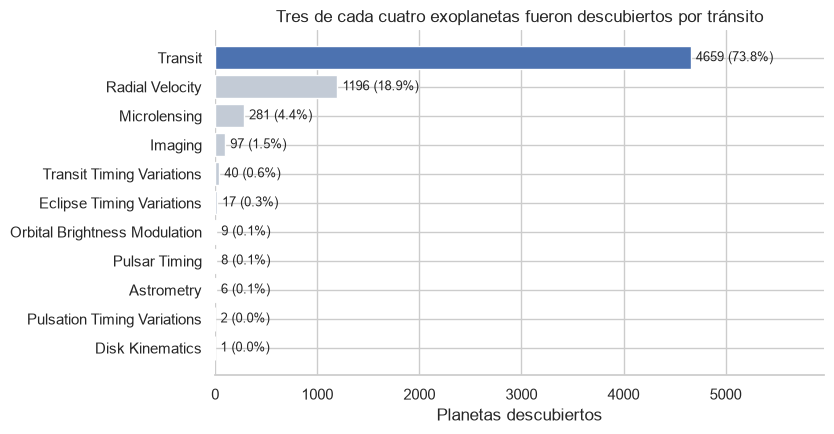

In [11]:
method_counts = df_clean["discoverymethod"].value_counts()
total = len(df_clean)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
# Destacar el método dominante; el resto queda en gris de contexto
colors = [ACCENT if m == "Transit" else MUTED for m in method_counts.index]
ax.barh(method_counts.index, method_counts.values, color=colors)
ax.invert_yaxis()  # el más frecuente arriba

# Etiquetas directas: con esta disparidad, leer el eje no alcanza
for i, val in enumerate(method_counts.values):
    ax.text(val + total * 0.008, i, f"{val} ({val / total * 100:.1f}%)",
            va="center", fontsize=9)

ax.set_xlim(0, method_counts.max() * 1.28)
ax.set_xlabel("Planetas descubiertos")
ax.set_title("Tres de cada cuatro exoplanetas fueron descubiertos por tránsito")
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Conclusión:** el tránsito aporta el **73,8%** de todos los exoplanetas
conocidos, y la velocidad radial otro 18,9%: entre los dos concentran el 93%
del catálogo. Cualquier afirmación sobre "el exoplaneta típico" es, en la
práctica, una afirmación sobre lo que estos dos métodos son capaces de ver.
Los otros nueve métodos juntos aportan menos del 8% — y como vimos en 2.4,
son justamente los que exploran las regiones donde tránsito y velocidad
radial son ciegos.

### 3.2 ¿Cómo evolucionó el ritmo de descubrimientos?

**Pregunta:** ¿los exoplanetas se descubren a un ritmo constante, o hay
quiebres en la serie temporal?

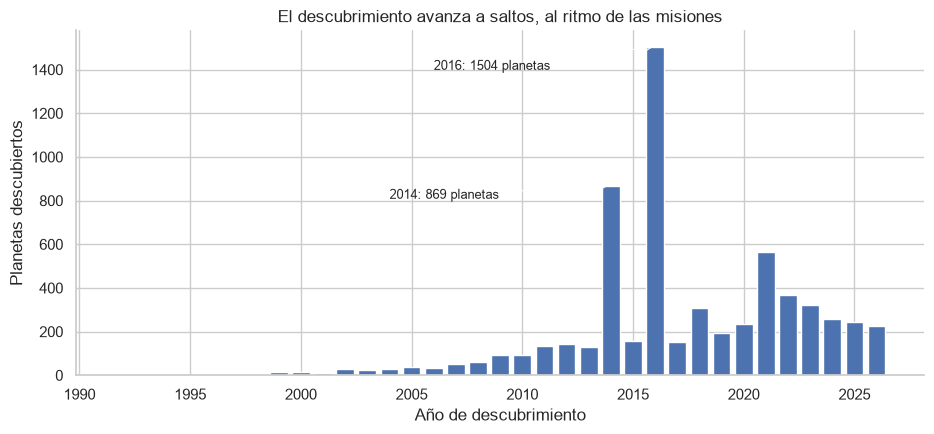

In [12]:
year_counts = df_clean["disc_year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(year_counts.index, year_counts.values, color=ACCENT, width=0.8)

# Anotar los dos años peak (corresponden a validaciones masivas del catálogo Kepler)
for year, count in year_counts.nlargest(2).items():
    ax.annotate(f"{year}: {count} planetas", xy=(year, count),
                xytext=(year - 10, count * 0.93),
                arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=9)

ax.set_xlabel("Año de descubrimiento")
ax.set_ylabel("Planetas descubiertos")
ax.set_title("El descubrimiento avanza a saltos, al ritmo de las misiones")
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** el descubrimiento no avanza parejo — salta con cada
instrumento. Hasta 2009 (era de la velocidad radial, desde telescopios en
tierra) se confirmaban decenas de planetas al año. El telescopio espacial
Kepler (2009) industrializó el método del tránsito, y los dos peaks del
gráfico no son años milagrosos: son **publicaciones masivas de validaciones
del catálogo Kepler**. El ritmo lo dictan los instrumentos y sus pipelines de
análisis, no un progreso continuo. (El último año aparece bajo simplemente
porque aún no termina.)

### 3.3 ¿Cómo se distribuyen las variables físicas clave?

**Pregunta:** ¿qué forma tienen las distribuciones de radio, masa y período
orbital?

El perfilado (2.5) mostró que estas variables abarcan varios órdenes de
magnitud, así que los histogramas usan bins logarítmicos — en escala lineal
todo el detalle quedaría aplastado contra el origen.

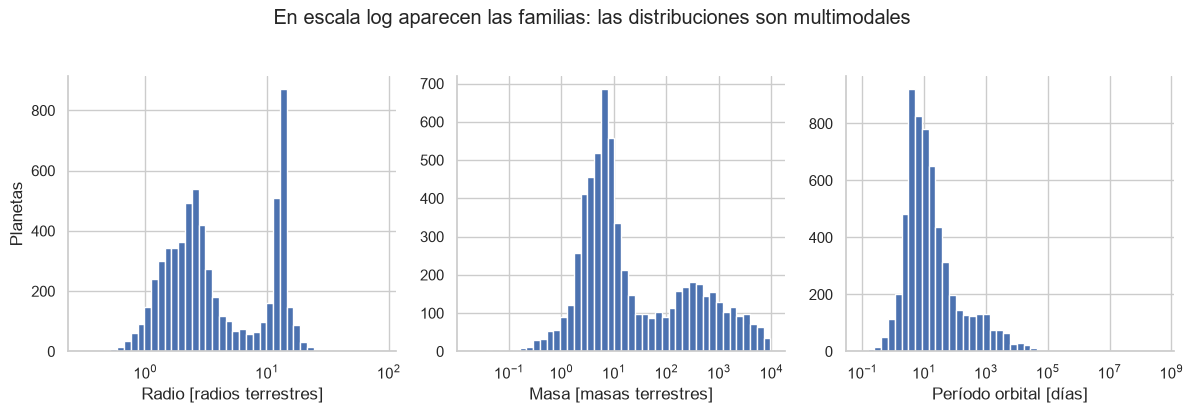

In [13]:
phys_vars = [
    ("pl_rade", "Radio [radios terrestres]"),
    ("pl_bmasse", "Masa [masas terrestres]"),
    ("pl_orbper", "Período orbital [días]"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (col, label) in zip(axes, phys_vars):
    data = df_clean[col].dropna()
    # Bins log-espaciados: estas variables viven en órdenes de magnitud,
    # con bins lineales todo se apila en la primera barra
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 45)
    ax.hist(data, bins=bins, color=ACCENT)
    ax.set_xscale("log")
    ax.set_xlabel(label)
axes[0].set_ylabel("Planetas")
fig.suptitle("En escala log aparecen las familias: las distribuciones son multimodales",
             y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** las tres distribuciones solo se leen en escala logarítmica. El
radio es bimodal: abundan los planetas de 1–3 radios terrestres (super-Tierras
y sub-Neptunos, familias que no existen en el Sistema Solar) y los gigantes
tipo Júpiter (~10–15 radios). La masa repite el patrón a su manera. Y el
período orbital es lo más revelador: **la mitad del catálogo orbita en menos
de 11 días** — mucho más cerca de su estrella que Mercurio del Sol (88 días).
¿Son realmente los planetas "pegados" a su estrella los más comunes del
universo, o solo los más fáciles de detectar? Esa es exactamente la pregunta
de la sección 4.

## 4. EDA bivariado: cada método ve un universo distinto

El núcleo del análisis. La sección 3 mostró *qué* hay en el catálogo; esta
sección muestra que ese contenido **depende de cómo se buscó**. Cruzamos el
método de detección con las variables físicas para hacer visible el sesgo:
si los métodos fueran ventanas neutras, las distribuciones por método serían
parecidas. No lo son — y esa es la tesis.

Desde aquí usamos `method_grouped` (los 4 métodos principales + `Other`),
con un color fijo por método en todos los gráficos.

In [14]:
# Orden y colores fijos por método para toda la sección:
# el lector asocia un color a un método una sola vez
# (paleta apta para daltonismo, basada en la "colorblind" de seaborn)
METHOD_ORDER = ["Transit", "Radial Velocity", "Microlensing", "Imaging", "Other"]
METHOD_COLORS = {
    "Transit": "#0173B2",          # azul
    "Radial Velocity": "#DE8F05",  # naranjo
    "Microlensing": "#029E73",     # verde
    "Imaging": "#D55E00",          # rojo ladrillo
    "Other": "#949494",            # gris
}

### 4.1 ¿Qué tamaño de planeta descubre cada método?

**Pregunta:** ¿la masa de los planetas encontrados depende del método que los
encontró?

Comparamos con boxplots la distribución de masa por método. Como la masa
abarca 5 órdenes de magnitud (2.5), el eje va en escala logarítmica.

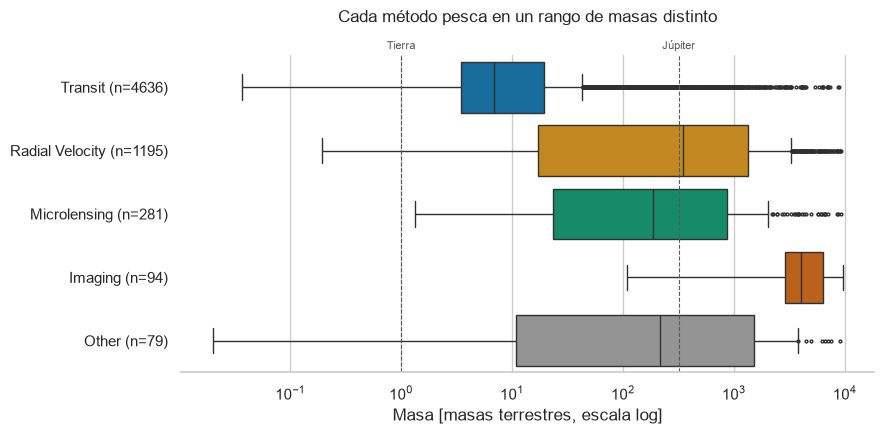

In [15]:
data = df_clean.dropna(subset=["pl_bmasse"])
counts = data["method_grouped"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=data, y="method_grouped", x="pl_bmasse", order=METHOD_ORDER,
            hue="method_grouped", palette=METHOD_COLORS, legend=False,
            fliersize=2, ax=ax)
ax.set_xscale("log")

# Masas de referencia del Sistema Solar (etiquetas sobre el borde superior)
for mass, name in [(1.0, "Tierra"), (317.8, "Júpiter")]:
    ax.axvline(mass, color="0.35", lw=0.8, ls="--")
    ax.text(mass, -0.6, name, fontsize=8, color="0.35", ha="center")

ax.set_xlabel("Masa [masas terrestres, escala log]")
ax.set_ylabel("")
ax.set_yticks(range(len(METHOD_ORDER)),
              [f"{m} (n={counts[m]})" for m in METHOD_ORDER])
ax.set_title("Cada método pesca en un rango de masas distinto", pad=24)
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Conclusión:** la mediana de masa cambia **~600 veces** según a qué método le
preguntes: 6,9 M⊕ en tránsito (super-Tierras y sub-Neptunos), ~350 M⊕
(≈1,1 masas de Júpiter) en velocidad radial, ~190 M⊕ en microlente y ~4.100 M⊕
(≈13 M_Júp, al borde del límite con las enanas cafés) en imagen directa. No es
que existan "los planetas típicos": cada técnica pesca en un estanque de masas
distinto. Nota de honestidad: el 64% de las masas de tránsito son estimaciones
M-R (sección 2.3) — suficiente para comparar órdenes de magnitud, no valores
finos.

### 4.2 ¿Los métodos favorecen planetas cercanos o lejanos a su estrella?

**Pregunta:** ¿a qué distancia de su estrella están los planetas que cada
método encuentra?

Usamos el semi-eje mayor (`pl_orbsmax`) y no el período: representa la misma
física (qué tan lejos orbita el planeta) pero tiene muchos menos nulos en
microlente e imagen directa (ver 2.4), justo los métodos que exploran las
distancias grandes.

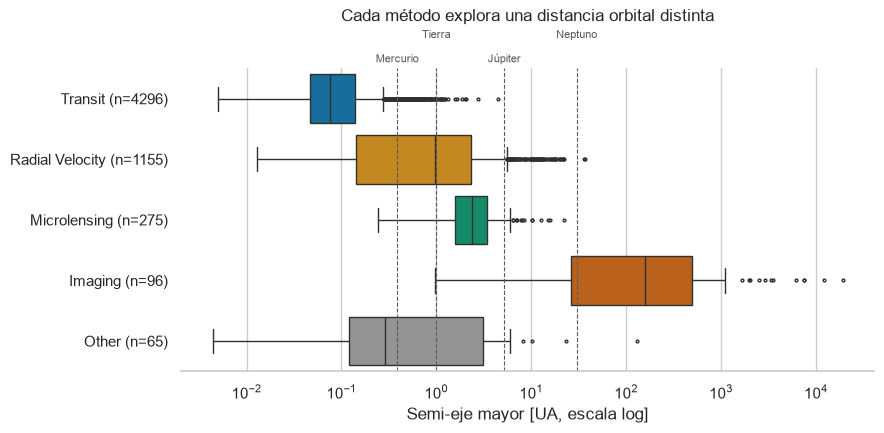

In [16]:
data = df_clean.dropna(subset=["pl_orbsmax"])
counts = data["method_grouped"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=data, y="method_grouped", x="pl_orbsmax", order=METHOD_ORDER,
            hue="method_grouped", palette=METHOD_COLORS, legend=False,
            fliersize=2, ax=ax)
ax.set_xscale("log")

# Órbitas del Sistema Solar; las etiquetas alternan altura para no chocar
# (Mercurio y Tierra quedan muy juntos en escala log)
refs = [(0.387, "Mercurio", -0.6), (1.0, "Tierra", -1.0),
        (5.2, "Júpiter", -0.6), (30.1, "Neptuno", -1.0)]
for au, name, y_label in refs:
    ax.axvline(au, color="0.35", lw=0.8, ls="--")
    ax.text(au, y_label, name, fontsize=8, color="0.35", ha="center")

ax.set_xlabel("Semi-eje mayor [UA, escala log]")
ax.set_ylabel("")
ax.set_yticks(range(len(METHOD_ORDER)),
              [f"{m} (n={counts[m]})" for m in METHOD_ORDER])
ax.set_title("Cada método explora una distancia orbital distinta", pad=34)
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Conclusión:** los métodos no compiten — se reparten el sistema planetario
casi sin solaparse. El tránsito vive pegado a la estrella (mediana 0,076 UA,
cinco veces más adentro que Mercurio), velocidad radial llega hasta ~1 UA,
microlente puebla la franja fría de 1,6–3,4 UA (cerca de la "línea de hielo",
donde se forman los gigantes), e imagen directa parte donde todos los demás
terminan (mediana 156 UA, cinco veces la órbita de Neptuno). La región
5–25 UA — donde viven Júpiter, Saturno y Urano — queda en un vacío de
cobertura: si nuestro propio Sistema Solar orbitara otra estrella, casi no
podríamos detectarlo.

### 4.3 El mapa completo: masa vs. distancia orbital, coloreado por método

**Pregunta:** ¿cómo se reparte el espacio de parámetros completo entre los
métodos — y dónde caería el Sistema Solar en ese mapa?

**Nota de diseño:** el plan natural era graficar masa vs. *período orbital*,
pero la sección 2.4 mostró que el período falta justo donde más importa: 96%
de nulos en microlente y 74% en imagen directa. Usar el período borraría del
mapa a los dos métodos que ven lo que tránsito y velocidad radial no ven —
amputaría el sesgo que queremos mostrar. Usamos el **semi-eje mayor** (6,8%
de nulos): representa la misma física (distancia a la estrella) y por la
tercera ley de Kepler ($P^2 \propto a^3$) es informacionalmente equivalente.

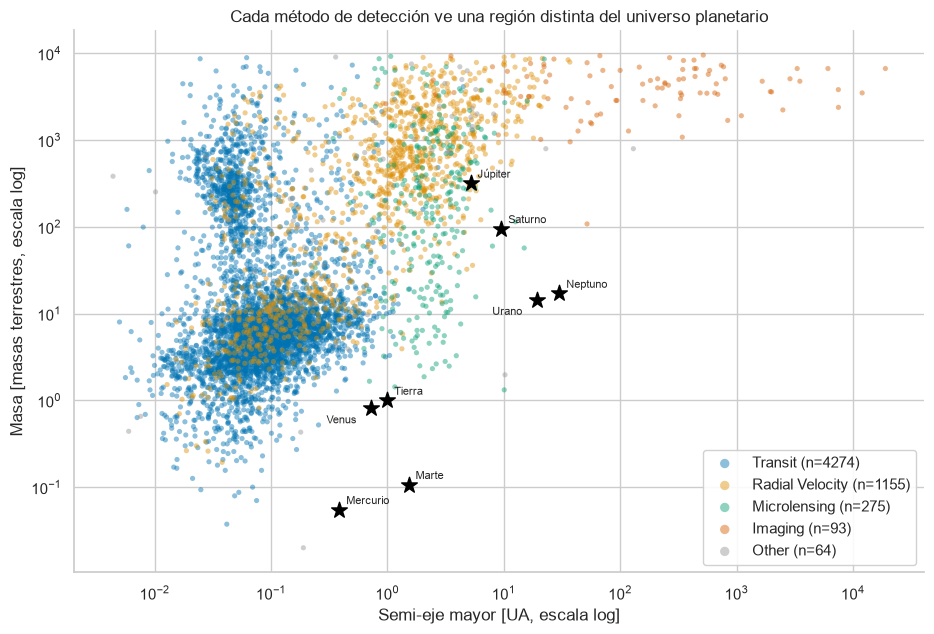

In [17]:
data = df_clean.dropna(subset=["pl_bmasse", "pl_orbsmax"])

fig, ax = plt.subplots(figsize=(9.5, 6.5))
for method in METHOD_ORDER:
    sub = data[data["method_grouped"] == method]
    ax.scatter(sub["pl_orbsmax"], sub["pl_bmasse"], s=14, alpha=0.45,
               color=METHOD_COLORS[method], label=f"{method} (n={len(sub)})",
               edgecolors="none")

# El Sistema Solar como referencia: ¿dónde caerían nuestros propios planetas?
solar_system = {
    "Mercurio": (0.387, 0.055), "Venus": (0.723, 0.815), "Tierra": (1.0, 1.0),
    "Marte": (1.524, 0.107), "Júpiter": (5.203, 317.8), "Saturno": (9.537, 95.2),
    "Urano": (19.19, 14.5), "Neptuno": (30.07, 17.1),
}
# Venus y Urano llevan la etiqueta a la izquierda para no chocar
# con Tierra y Neptuno, sus vecinos en el plano
label_offsets = {"Venus": (-32, -11), "Urano": (-32, -11)}
for name, (a, m) in solar_system.items():
    ax.scatter(a, m, marker="*", s=140, color="black", zorder=5)
    ax.annotate(name, (a, m), xytext=label_offsets.get(name, (5, 4)),
                textcoords="offset points", fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Semi-eje mayor [UA, escala log]")
ax.set_ylabel("Masa [masas terrestres, escala log]")
ax.set_title("Cada método de detección ve una región distinta del universo planetario")
ax.legend(loc="lower right", framealpha=0.9, markerscale=1.8)
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** el plano masa–distancia está repartido en territorios casi
disjuntos: tránsito (azul) domina abajo a la izquierda — planetas pequeños
pegados a su estrella —, velocidad radial (naranjo) los gigantes a distancias
intermedias, microlente (verde) la franja fría de 1–10 UA, e imagen directa
(rojo) los super-Júpiters a decenas o cientos de UA. Las estrellas negras del
Sistema Solar muestran el punto ciego: **la Tierra cae en tierra de nadie**,
una región donde ningún método es eficiente, y nuestros gigantes (5–30 UA)
quedan en el hueco entre velocidad radial e imagen directa. Un Júpiter
caliente parece "típico" no porque abunde, sino porque dos métodos lo ven
fácil. **El catálogo es el mapa de nuestras herramientas, no del territorio.**

## 5. Modelado ligero A: ¿cuántos mundos se parecen a casa?

La pregunta emocional del proyecto, aterrizada a un criterio cuantitativo.
Definimos un filtro simple y defendible con las dos variables físicas que
mejor lo permiten:

- **Radio entre 0,5 y 1,6 R⊕** — los estudios de densidad muestran que bajo
  ~1,6 radios terrestres la mayoría de los planetas son rocosos (Rogers,
  2015); sobre ese umbral dominan las envolturas de gas.
- **Temperatura de equilibrio entre 180 y 310 K** — rango compatible con agua
  líquida en superficie, con margen para el efecto invernadero (la T$_{eq}$
  de la Tierra es 255 K; su superficie real promedia 288 K gracias a la
  atmósfera).

No es machine learning y no pretende serlo: es una **regla transparente**
cuyos umbrales se pueden discutir uno a uno — que es exactamente lo que la
hace defendible. Las limitaciones quedan explícitas al final de la sección.

### 5.1 El embudo: ¿cuántos planetas sobreviven el filtro?

**Pregunta:** aplicando los dos criterios en cadena, ¿cuántos mundos
"parecidos a casa" hay en el catálogo?

In [18]:
# Umbrales del filtro (justificados en la celda anterior)
R_MIN, R_MAX = 0.5, 1.6    # radios terrestres
T_MIN, T_MAX = 180, 310    # Kelvin

base = df_clean.dropna(subset=["pl_rade", "pl_eqt"])
rocky = base[base["pl_rade"].between(R_MIN, R_MAX)]
candidates = rocky[rocky["pl_eqt"].between(T_MIN, T_MAX)]

funnel = pd.Series({
    "Catálogo completo": len(df_clean),
    "Con radio y Teq disponibles": len(base),
    f"Rocosos ({R_MIN}-{R_MAX} R⊕)": len(rocky),
    f"...y templados ({T_MIN}-{T_MAX} K)": len(candidates),
}, name="planetas").to_frame()
funnel["% del catálogo"] = (funnel["planetas"] / len(df_clean) * 100).round(1)
funnel

,planetas,% del catálogo
Catálogo completo,6316,100.0
Con radio y Teq disponibles,5751,91.1
Rocosos (0.5-1.6 R⊕),1122,17.8
...y templados (180-310 K),36,0.6


**Conclusión:** de 6.316 planetas, 5.751 tienen radio y temperatura medidos —
y el primer recorte ya es sesgo puro: exigir T$_{eq}$ expulsa del ejercicio a
prácticamente toda la microlente y la imagen directa (98–100% de nulos,
sección 2.4). De los que quedan, 1.122 son rocosos, pero solo **36 son
rocosos *y* templados: el 0,6% del catálogo**. La frase para el post ya
existe: *de 6.316 mundos conocidos, solo 36 se parecen a casa*.

### 5.2 ¿Dónde viven los candidatos en el plano radio–temperatura?

**Pregunta:** ¿qué tan especial es la combinación "rocoso y templado" dentro
del catálogo?

Dibujamos todos los planetas en el plano T$_{eq}$ vs. radio, con la caja del
filtro superpuesta — así el criterio deja de ser un par de números y se ve
como región. Agregamos la Tierra, Venus y Marte como referencia.

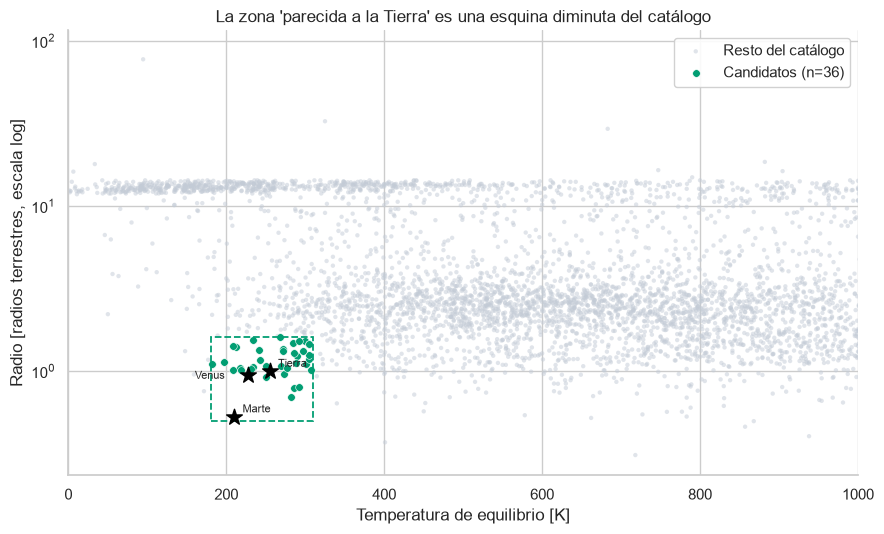

In [19]:
from matplotlib.patches import Rectangle

base = df_clean.dropna(subset=["pl_rade", "pl_eqt"])
cand_mask = (base["pl_rade"].between(R_MIN, R_MAX)
             & base["pl_eqt"].between(T_MIN, T_MAX))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(base.loc[~cand_mask, "pl_eqt"], base.loc[~cand_mask, "pl_rade"],
           s=10, color=MUTED, alpha=0.5, edgecolors="none",
           label="Resto del catálogo")
ax.scatter(base.loc[cand_mask, "pl_eqt"], base.loc[cand_mask, "pl_rade"],
           s=30, color="#029E73", edgecolors="white", linewidths=0.4,
           label=f"Candidatos (n={cand_mask.sum()})")

# La caja del filtro, dibujada sobre los datos
ax.add_patch(Rectangle((T_MIN, R_MIN), T_MAX - T_MIN, R_MAX - R_MIN,
                       fill=False, edgecolor="#029E73", lw=1.3, ls="--"))

# Referencias del Sistema Solar (con sus Teq reales)
refs = [("Tierra", 255, 1.0, (6, 3)), ("Venus", 227, 0.95, (-38, -3)),
        ("Marte", 210, 0.53, (6, 3))]
for name, teq, radius, offset in refs:
    ax.scatter(teq, radius, marker="*", s=140, color="black", zorder=5)
    ax.annotate(name, (teq, radius), xytext=offset,
                textcoords="offset points", fontsize=8)

# Recorte visual (no de datos): sobre 1000 K solo quedan planetas asados
ax.set_xlim(0, 1000)
ax.set_yscale("log")
ax.set_xlabel("Temperatura de equilibrio [K]")
ax.set_ylabel("Radio [radios terrestres, escala log]")
ax.set_title("La zona 'parecida a la Tierra' es una esquina diminuta del catálogo")
ax.legend(loc="upper right", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** la zona "parecida a la Tierra" es una esquina diminuta del
plano — y casi vacía. El grueso del catálogo vive muy por encima (más grande)
o muy a la derecha (más caliente) de la caja. Y hay una advertencia
incorporada en el propio gráfico: **Venus también cae dentro del filtro**, y
su superficie derrite plomo (~460 °C). La temperatura de equilibrio ignora la
atmósfera; este filtro encuentra *candidatos*, no gemelos confirmados.

### 5.3 ¿Quiénes son los candidatos y qué tienen en común?

**Pregunta:** ordenados por parecido a la Tierra, ¿quiénes encabezan la lista
— y qué tipo de estrella orbitan?

Para rankear usamos un score inspirado en el *Earth Similarity Index* (ESI):
para cada variable se calcula un término de similitud $1 - \frac{|x - x_\oplus|}{x + x_\oplus}$
(que vale 1 si el planeta es idéntico a la Tierra y cae hacia 0 al alejarse) y
el score es la media geométrica de los términos de radio y temperatura. Es
una regla transparente y reproducible — no un modelo entrenado.

In [20]:
def similarity(x, ref):
    """Término de similitud del Earth Similarity Index: 1 = idéntico a la Tierra."""
    return 1 - abs(x - ref) / (x + ref)

# Score: media geométrica de las similitudes en radio y temperatura
# (referencias de la Tierra: 1 radio terrestre, Teq = 255 K)
candidates = candidates.copy()
candidates["esi"] = np.sqrt(similarity(candidates["pl_rade"], 1.0)
                            * similarity(candidates["pl_eqt"], 255.0))

print(f"Temperatura estelar mediana de los candidatos: "
      f"{candidates['st_teff'].median():.0f} K (el Sol: 5772 K)")
print(f"Candidatos con masa estimada (no medida): "
      f"{candidates['mass_is_estimated'].sum()} de {len(candidates)}\n")

top10 = (candidates.sort_values("esi", ascending=False)
         [["pl_name", "method_grouped", "disc_year", "pl_rade", "pl_bmasse",
           "mass_is_estimated", "pl_eqt", "st_teff", "sy_dist", "esi"]]
         .head(10).round(3))
top10

Temperatura estelar mediana de los candidatos: 3176 K (el Sol: 5772 K)
Candidatos con masa estimada (no medida): 12 de 36



,pl_name,method_grouped,disc_year,pl_rade,pl_bmasse,mass_is_estimated,pl_eqt,st_teff,sy_dist,esi
5279,Wolf 1069 b,Radial Velocity,2023,1.080,1.260,False,250.10,3158.0,9.583,0.976
778,TRAPPIST-1 e,Transit,2017,0.920,0.692,False,249.70,2566.0,12.430,0.974
909,TOI-700 e,Transit,2023,0.953,0.818,True,272.90,3459.0,31.126,0.971
843,TOI-700 d,Transit,2020,1.073,1.250,True,268.80,3459.0,31.126,0.969
6013,GJ 1002 b,Radial Velocity,2022,1.030,1.080,False,230.90,3024.0,4.849,0.968
4844,Teegarden's Star b,Radial Velocity,2019,1.050,1.160,False,277.00,3034.0,3.831,0.967
1810,Kepler-1649 c,Transit,2020,1.060,1.200,True,234.00,3240.0,92.191,0.964
2350,Proxima Cen b,Radial Velocity,2016,1.020,1.055,False,218.00,2900.0,1.301,0.955
6196,GJ 1061 d,Radial Velocity,2020,1.160,1.670,False,242.03,2953.0,3.673,0.950
779,TRAPPIST-1 f,Transit,2017,1.045,1.039,False,217.70,2566.0,12.430,0.949


**Conclusión:** el ranking valida el score sin haberlo entrenado con nada: a
la cabeza quedan los candidatos famosos de la literatura — TRAPPIST-1 e,
Proxima Cen b, TOI-700 d, Teegarden's Star b. Pero la columna `st_teff`
esconde el hallazgo grande: la mediana estelar de los candidatos es **~3.180 K
— casi todos orbitan enanas rojas**, no estrellas como el Sol (5.772 K). Otra
vez el sesgo de detección: la zona templada de una enana roja está a días de
período orbital (detectable por tránsito y velocidad radial), la de un sol
está a 1 UA y 365 días (casi invisible). **No encontramos "Tierras alrededor
de soles" porque no podemos, no porque no existan.** Y las enanas rojas traen
letra chica: acoplamiento de marea y fulguraciones que complican la
habitabilidad real.

### 5.4 Limitaciones de este ejercicio

Ser explícito sobre lo que este score **no** dice vale tanto como el score:

- **La T$_{eq}$ no es la temperatura de la superficie.** Ignora atmósfera y
  efecto invernadero — por eso Venus pasa el filtro. Un candidato podría ser
  un Venus, un Marte congelado o una Tierra: con estas columnas no se
  distingue.
- **Dos variables no hacen habitabilidad.** Agua, placas tectónicas, campo
  magnético, actividad de la estrella: nada de eso está en el dataset. Este
  filtro encuentra *candidatos que ameritan seguimiento*, no gemelos de la
  Tierra.
- **12 de los 36 candidatos tienen masa estimada** por relación M-R (no
  medida), y las T$_{eq}$ publicadas dependen del albedo que asumió cada
  autor.
- **La muestra misma está sesgada** (sección 4): solo podemos filtrar los
  planetas que nuestros métodos alcanzan a ver y caracterizar. El "0,6% del
  catálogo" no es el 0,6% de la galaxia.

## 6. Modelado ligero B: ¿k-means redescubre las familias de planetas?

Si las "familias" de planetas (Júpiters calientes, super-Tierras, gigantes
fríos...) son estructura real de los datos y no solo nombres, un algoritmo de
clustering **sin supervisión** — que no sabe nada de astronomía — debería
encontrarlas solo.

**Features:** masa, radio y semi-eje mayor (la misma justificación de 4.3
para preferir semi-eje sobre período). **Preprocesamiento en dos pasos, ambos
obligatorios:**

1. **log10**: las features abarcan órdenes de magnitud; en escala lineal, la
   diferencia entre dos gigantes (300 vs. 3.000 M⊕) aplastaría la diferencia
   entre una Tierra y un Neptuno (1 vs. 17 M⊕), que es la que importa.
2. **Estandarización** (`StandardScaler`): k-means agrupa por distancia
   euclidiana, que suma las diferencias de todas las features *en sus
   unidades originales*. Sin escalar, la feature con el rango numérico más
   grande decide todo.

Para que el punto 2 no quede en teoría, la celda siguiente muestra qué pasa
si nos saltamos el preprocesamiento.

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

FEATURES = ["pl_bmasse", "pl_rade", "pl_orbsmax"]
data = df_clean.dropna(subset=FEATURES).copy()

# Paso 1: log10 — las tres features viven en órdenes de magnitud (sección 2.5)
X_log = np.log10(data[FEATURES])
# Paso 2: estandarizar — media 0 y desviación 1 para que las tres pesen igual
X = StandardScaler().fit_transform(X_log)

# Demostración del error clásico: el mismo k-means sobre los datos crudos
sizes_raw = np.sort(np.bincount(
    KMeans(n_clusters=4, n_init=10, random_state=42)
    .fit(data[FEATURES]).labels_))[::-1]
sizes_ok = np.sort(np.bincount(
    KMeans(n_clusters=4, n_init=10, random_state=42)
    .fit(X).labels_))[::-1]

print(f"{len(data)} planetas con las 3 features completas\n")
print(f"Tamaños de cluster SIN log ni escalado: {sizes_raw}")
print(f"Tamaños de cluster CON log + escalado:  {sizes_ok}")

5822 planetas con las 3 features completas

Tamaños de cluster SIN log ni escalado: [5314  385  118    5]
Tamaños de cluster CON log + escalado:  [2211 1625 1009  977]


**Conclusión de la demostración:** sin preprocesar, k-means devuelve un
cluster gigante y tres grupos residuales — está agrupando solo por masa,
porque la masa (0,02–9.535) tiene un rango miles de veces mayor que el radio
(0,3–87) y el semi-eje domina aún menos. La distancia euclidiana no sabe de
unidades: la feature con números más grandes manda. Con log + estandarización,
las tres features votan por igual y emergen grupos de tamaños razonables.
**Este es el error #1 en clustering, y la solución son dos líneas.**

### 6.1 ¿Cuántos clusters? Codo y silueta

**Pregunta:** ¿qué k usar? k-means no lo decide solo — hay que elegirlo con
un criterio.

Usamos dos métricas complementarias: la **inercia** (suma de distancias al
centroide; siempre baja al subir k, buscamos el "codo" donde deja de bajar
rápido) y el **coeficiente de silueta** (qué tan bien separado está cada
punto de los clusters vecinos; mayor es mejor).

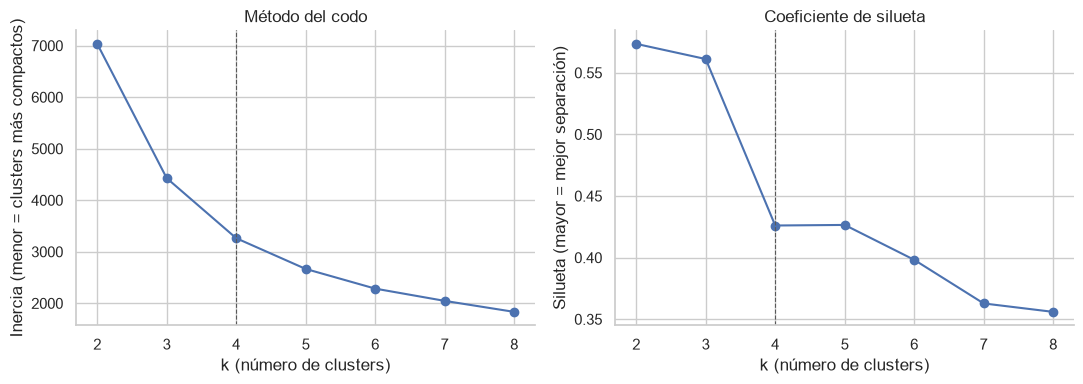

In [22]:
ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, marker="o", color=ACCENT)
axes[0].set_ylabel("Inercia (menor = clusters más compactos)")
axes[0].set_title("Método del codo")
axes[1].plot(ks, silhouettes, marker="o", color=ACCENT)
axes[1].set_ylabel("Silueta (mayor = mejor separación)")
axes[1].set_title("Coeficiente de silueta")
for ax in axes:
    ax.set_xlabel("k (número de clusters)")
    ax.axvline(4, color="0.35", lw=0.8, ls="--")  # el k elegido
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** las dos métricas no coinciden — y eso es normal. La silueta
es máxima en k=2–3: la macro-división "planetas chicos vs. gigantes" es lo
más separable. El codo de la inercia se dobla entre 3 y 4. Elegimos **k=4**
por interpretabilidad: como se ve a continuación, cada cluster adicional
hasta 4 corresponde a una familia astronómica conocida, mientras que la
silueta de k=5 ya no mejora (0,427 vs. 0,426) y más allá todo empeora. La
elección de k siempre mezcla métrica y criterio de dominio; lo importante es
explicitar ambos.

### 6.2 ¿Qué familias emergen?

**Pregunta:** con k=4, ¿los grupos que encuentra el algoritmo corresponden a
las familias de planetas que la astronomía conoce?

Ajustamos el modelo final, perfilamos cada cluster con sus medianas y le
ponemos nombre según su física. Ojo con el orden: primero el algoritmo
agrupa, después nosotros interpretamos — no al revés.

In [23]:
K_FINAL = 4
km = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42).fit(X)
data["cluster"] = km.labels_

# Perfil de cada cluster: medianas de las features (+ Teq como contexto)
profile = data.groupby("cluster")[FEATURES + ["pl_eqt"]].median().round(2)
profile.insert(0, "n", data["cluster"].value_counts())


def name_cluster(row):
    """Etiqueta interpretativa según el perfil físico del cluster."""
    if row["pl_bmasse"] > 100:  # gigantes gaseosos
        return "Júpiters calientes" if row["pl_orbsmax"] < 0.5 else "Gigantes fríos"
    return "Sub-Neptunos" if row["pl_rade"] > 2 else "Super-Tierras calientes"


cluster_names = profile.apply(name_cluster, axis=1)
profile.insert(0, "familia", cluster_names)
profile

,familia,n,pl_bmasse,pl_rade,pl_orbsmax,pl_eqt
cluster,,,,,,
0,Super-Tierras calientes,1625,2.76,1.44,0.05,918.50
1,Júpiters calientes,977,263.80,12.81,0.05,1284.45
2,Sub-Neptunos,2211,8.40,2.73,0.14,638.59
3,Gigantes fríos,1009,937.60,13.00,2.32,259.15


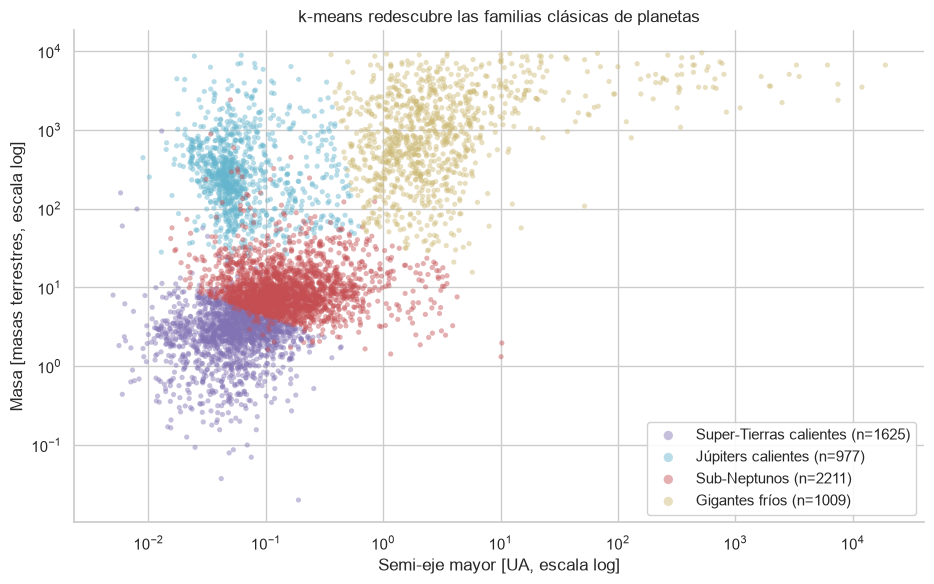

In [24]:
# Las familias en el mismo plano masa-distancia del gráfico estrella (4.3)
CLUSTER_COLORS = ["#8172B3", "#64B5CD", "#C44E52", "#CCB974"]

fig, ax = plt.subplots(figsize=(9.5, 6))
for cluster_id, name in cluster_names.items():
    sub = data[data["cluster"] == cluster_id]
    ax.scatter(sub["pl_orbsmax"], sub["pl_bmasse"], s=14, alpha=0.45,
               color=CLUSTER_COLORS[cluster_id], edgecolors="none",
               label=f"{name} (n={len(sub)})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Semi-eje mayor [UA, escala log]")
ax.set_ylabel("Masa [masas terrestres, escala log]")
ax.set_title("k-means redescubre las familias clásicas de planetas")
ax.legend(loc="lower right", framealpha=0.9, markerscale=1.8)
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión:** sin saber nada de astronomía, k-means redescubrió las
categorías que los astrónomos definieron a mano durante décadas:

- **Super-Tierras calientes** (~2,8 M⊕, 1,4 R⊕, 0,05 UA): rocosos pegados a
  su estrella.
- **Sub-Neptunos** (~8,4 M⊕, 2,7 R⊕): la familia más numerosa del catálogo —
  y un tipo de planeta que el Sistema Solar no tiene.
- **Júpiters calientes** (~260 M⊕, 13 R⊕, 0,05 UA, ~1.300 K): gigantes
  asados en órbitas de días, la primera gran sorpresa de la exoplanetología
  (51 Pegasi b, 1995).
- **Gigantes fríos** (~940 M⊕, 2,3 UA, ~260 K): los parientes de Júpiter, a
  distancias donde el catálogo empieza a quedarse ciego.

En el mapa se ve además que la frontera entre familias corta el plano en
regiones coherentes — no son grupos arbitrarios.

### 6.3 ¿Quién descubrió cada familia?

**Pregunta:** si las familias son estructura física real, ¿los métodos de
detección las muestrean por igual — o cada familia es "propiedad" de un
método?

Este cruce conecta el clustering con la tesis del proyecto: cruzamos las
familias encontradas por k-means con el método de descubrimiento.

In [25]:
# Composición de cada familia por método de detección
data["familia"] = data["cluster"].map(cluster_names)
pd.crosstab(data["familia"], data["method_grouped"])

method_grouped,Imaging,Microlensing,Other,Radial Velocity,Transit
familia,,,,,
Gigantes fríos,92,203,25,655,34
Júpiters calientes,0,3,9,123,842
Sub-Neptunos,0,69,17,244,1881
Super-Tierras calientes,0,0,9,100,1516


**Conclusión:** la tabla remata la tesis del proyecto. Los **gigantes fríos**
son el único cluster con presencia fuerte de microlente (203), imagen directa
(92) y velocidad radial (655), y casi sin tránsito (34). Las tres familias
"calientes" son territorio tránsito. Es decir: **las familias de planetas que
un algoritmo ciego encuentra están alineadas con los métodos que las
descubrieron** — cada técnica no solo encuentra más o menos planetas, sino
*tipos* de planeta distintos.

Limitaciones del ejercicio: k-means asume clusters convexos y de varianza
comparable en el espacio escalado; el resultado depende de las 3 features
elegidas y del k; y los nombres de las familias son nuestra interpretación de
las medianas, no salidas del algoritmo. Aun así, que una técnica no
supervisada — sin saber nada de astronomía — reconstruya las categorías de
libro es evidencia de que esas familias son estructura real de los datos, no
convención.

## 7. Síntesis y conclusiones

Cinco hallazgos sostienen la tesis — *lo que sabemos de los exoplanetas está
moldeado por cómo los buscamos*:

1. **El 93% del catálogo proviene de solo dos métodos.** El tránsito aporta
   el 73,8% y la velocidad radial el 18,9%. "El exoplaneta típico" es, en
   rigor, "el exoplaneta típico que estos dos métodos pueden ver" (§3.1).
2. **Cada método ve un universo distinto.** La mediana de masa cambia ~600
   veces entre métodos (6,9 M⊕ en tránsito vs. ~4.100 en imagen directa) y la
   distancia orbital ~2.000 veces (0,076 UA vs. 156 UA). En el plano
   masa–distancia los métodos ocupan territorios casi disjuntos, y la Tierra
   cae en una zona que ningún método cubre bien: nuestro propio Sistema Solar
   sería casi indetectable (§4).
3. **Hasta la "completitud" del dataset es un sesgo.** El 47% de las masas
   son estimaciones por relación masa-radio (64% en tránsito), y el patrón de
   datos faltantes es la huella digital de cada técnica (MNAR): la limpieza
   ya era análisis (§2).
4. **Solo 36 de 6.316 mundos (0,6%) se parecen a casa** — rocosos y templados
   — y casi todos orbitan enanas rojas, no soles: la zona templada de una
   estrella como la nuestra está fuera del alcance actual (§5).
5. **Las familias de planetas son reales y k-means las redescubre** —
   super-Tierras, sub-Neptunos, Júpiters calientes y gigantes fríos emergen
   solas de masa+radio+órbita (con log y escalado mediante). Y cada familia
   fue descubierta por métodos distintos: estructura física y sesgo de
   detección, entrelazados (§6).

### 7.1 Limitaciones del análisis

Lo que este trabajo **no** puede afirmar, y por qué:

- **Describe el catálogo, no el universo.** Todo el análisis muestra el sesgo
  de detección, pero no lo corrige: no calculamos tasas de ocurrencia
  ajustadas por la probabilidad de detección de cada método. Las
  distribuciones mostradas son de los planetas *encontrados*, no de los que
  *existen*.
- **La mitad de las masas no son mediciones**: 47% del catálogo usa la
  relación masa-radio y ~15% son cotas inferiores (`Msini`). Los análisis de
  masa comparan órdenes de magnitud, no valores finos.
- **`PSCompPars` mezcla fuentes heterogéneas**: cada fila combina parámetros
  de publicaciones distintas (con supuestos distintos, p. ej. el albedo detrás
  de cada T$_{eq}$). Es el precio de tener una fila por planeta.
- **El catálogo está vivo**: los números exactos (6.316 planetas, 36
  candidatos) cambian con cada actualización del archivo. Las conclusiones
  estructurales — la forma del sesgo — son las que deberían sobrevivir.
- **El clustering depende de sus elecciones**: otras features u otro k darían
  otra partición; las 4 familias son una descripción útil, no la única.

### 7.2 Qué haría con más tiempo y datos

- **Corregir el sesgo en vez de solo mostrarlo**: estimar tasas de ocurrencia
  ponderando cada planeta por su probabilidad de detección (para tránsito es
  calculable: $P \approx R_\star / a$). Es el paso que separa "describir el
  catálogo" de "inferir la población real", y es un proyecto en sí mismo.
- **Más columnas**: excentricidad orbital, insolación, metalicidad estelar y
  los intervalos de incertidumbre de cada medición, que el archivo publica y
  aquí no usamos.
- **Comparar `PSCompPars` contra la tabla `PS`** (una fila por publicación)
  para cuantificar cuánto cambian las conclusiones según qué referencia se
  elige por planeta.
- **Clustering más expresivo**: GMM (clusters elípticos y probabilísticos) o
  DBSCAN (encuentra k solo y tolera ruido) para testear la robustez de las
  4 familias.
- **Un dashboard interactivo** (plotly/streamlit) sobre el gráfico estrella,
  con filtros por método y año — el formato natural para explorar este
  dataset.

### 7.3 Cierre: el mapa no es el territorio

Volvamos a la pregunta inicial: ¿qué sabemos de los exoplanetas? La respuesta
honesta es que **sabemos lo que nuestras herramientas nos dejan saber**. El
catálogo de 6.316 mundos no es una muestra aleatoria del universo: es la
unión de cuatro linternas distintas alumbrando rincones distintos de una
pieza oscura — y la pieza es mucho más grande que la suma de los círculos de
luz.

Esto no es un defecto del trabajo de los astrónomos; es la condición de todo
dato observacional. Y la lección es transferible a cualquier dominio:
**antes de preguntar qué dicen los datos, hay que preguntar cómo fueron
recolectados** — porque el proceso de recolección deja huellas en cada
distribución, cada valor faltante y cada "hallazgo".

Las misiones que vienen (el telescopio Roman con microlente a gran escala,
PLATO buscando Tierras en órbitas largas, los telescopios extremadamente
grandes para imagen directa) van a iluminar justo los huecos que este
análisis mostró vacíos. La predicción de esta tesis es verificable: cuando
esas linternas se enciendan, la "población conocida de exoplanetas" va a
cambiar de forma — aunque el universo no haya cambiado nada.